# Analisis y graficos

En esta libreta realizamos los analisis plateados en la [Libreta_planteamiento_de_insights](Libreta_planteamiento_de_insights.ipynb), usando los dos dataframes `df_player_latest` y `df_team_match` elaborados en la [Libreta_procesamiento_de_datos](Libreta_procesamiento_de_datos.ipynb).

## Lectura de datos y formateo basico

El script final va a continuar de la parte de procesado, por lo cual no se tendra que hacer lo que hacemos a continuacion. Esto solo es para segmentar los avances en distintas libretas de jupyter.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

In [3]:
df_team_match = pd.read_csv("../OUTPUTS/df_team_match.csv")
df_player_latest_imputed = pd.read_csv("../OUTPUTS/df_player_latest_imputed.csv")
df_player_latest = pd.read_csv("../OUTPUTS/df_player_latest.csv")

df_team_match["DATE"] = pd.to_datetime(df_team_match["DATE"], errors="coerce").dt.floor("s")

df_player_latest["DATE"] = pd.to_datetime(df_player_latest["DATE"], errors="coerce").dt.floor("s")
df_player_latest["BIRTHDAY"] = pd.to_datetime(df_player_latest["BIRTHDAY"], errors="coerce").dt.floor("s")

df_player_latest_imputed["DATE"] = pd.to_datetime(df_player_latest_imputed["DATE"], errors="coerce").dt.floor("s")
df_player_latest_imputed["BIRTHDAY"] = pd.to_datetime(df_player_latest_imputed["BIRTHDAY"], errors="coerce").dt.floor("s")

# display(df_team_match.info())
# display(df_player_latest.info())
# display(df_player_latest_imputed.info())

In [9]:
COLOR_FONDO = "#F7F7F2"
COLOR_TEXTO = "#1F2937"
COLOR_GRID = "#D0D7DE"

COLOR_PRINCIPAL = "#1D4E89"
COLOR_SECUNDARIO = "#2A9D8F"
COLOR_RESALTE = "#E9C46A"
COLOR_ALERTA = "#D95D39"
COLOR_NEUTRO = "#8D99AE"

PALETA = [
    COLOR_PRINCIPAL,
    COLOR_SECUNDARIO,
    COLOR_RESALTE,
    COLOR_ALERTA,
    COLOR_NEUTRO,
    "#84A59D"
]

CMAP_CORR = "RdBu_r"

plt.rcParams.update({
    "figure.facecolor": COLOR_FONDO,
    "axes.facecolor": COLOR_FONDO,
    "savefig.facecolor": COLOR_FONDO,
    "axes.edgecolor": "#AAB4BE",
    "axes.labelcolor": COLOR_TEXTO,
    "axes.titlecolor": COLOR_TEXTO,
    "xtick.color": COLOR_TEXTO,
    "ytick.color": COLOR_TEXTO,
    "text.color": COLOR_TEXTO,
    "grid.color": COLOR_GRID,
    "grid.alpha": 0.35,
    "font.family": "sans-serif",
    "font.sans-serif": ["Aptos", "Segoe UI", "Calibri", "DejaVu Sans"],
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

## Analisis 01: Que atributos de jugador de campo aportan informacion nueva y cuales son redundantes?

- Pregunta: Que atributos conviene mirar juntos y cuales son casi equivalentes al evaluar futbolistas de campo?
- Que se calcula?: Una matriz de correlacion entre variables numericas de Player_Attributes enfocado en jugadores de campo.
- Datos a usar: df_player_latest
- Grafico: Heatmap de correlaciones.
- Insight esperado: Simplificar criterios de scouting y evitar evaluar como si fueran independientes atributos que casi siempre se mueven juntos.

Como el usar datos nan complicaria el analisis, usaremos el `df_player_latest_imputed`.

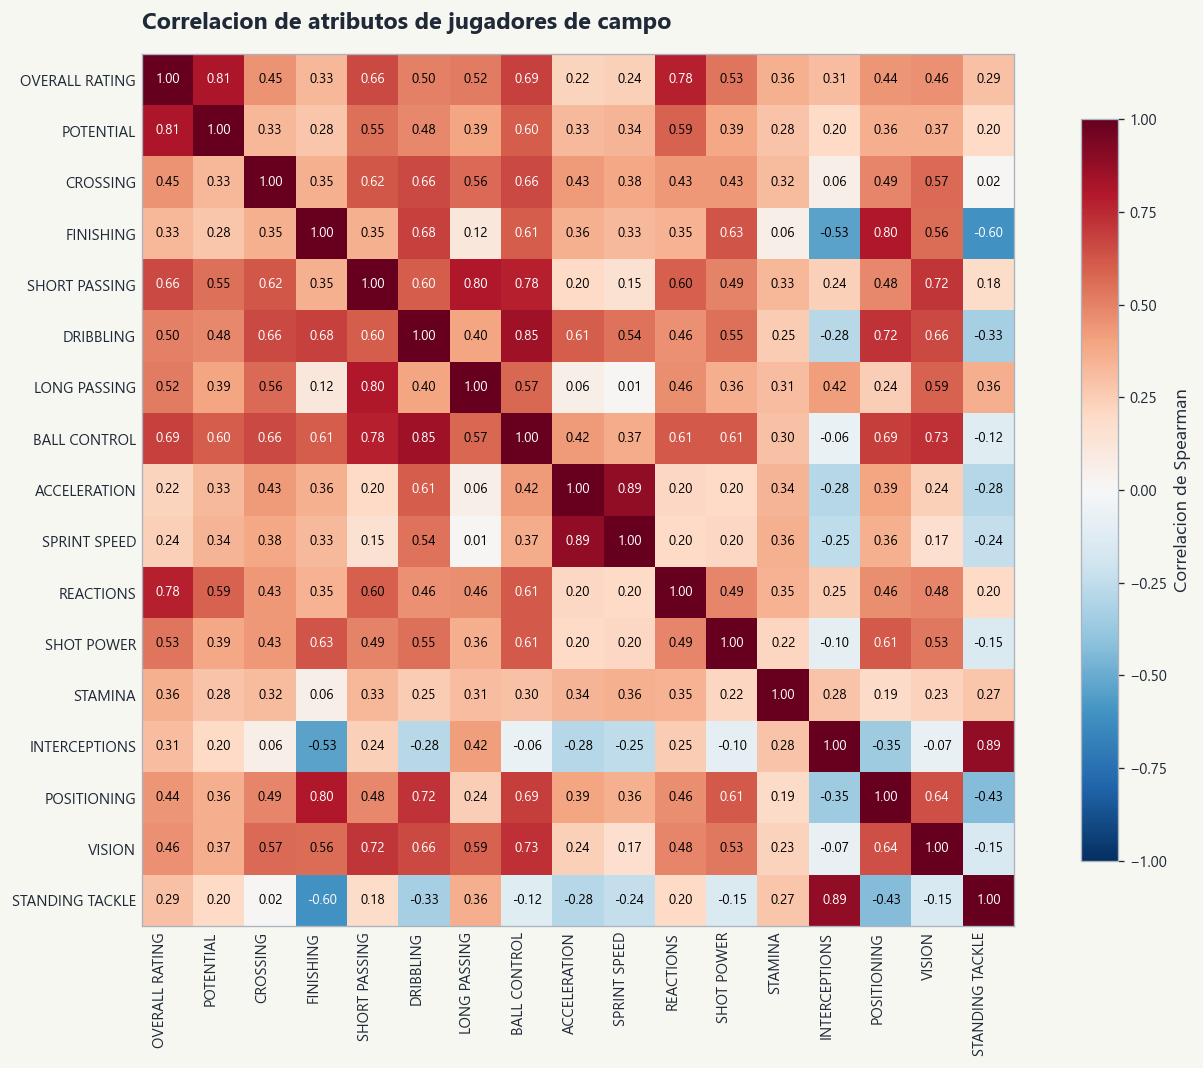

In [11]:
# Nos quedamos solo con jugadores de campo
df_outfield = df_player_latest_imputed.copy()
df_outfield = df_outfield[df_outfield["PLAYER_TYPE"] == "OUTFIELD"]

# Seleccionamos atributos relevantes para jugadores de campo
cols = [
    "OVERALL_RATING",
    "POTENTIAL",
    "CROSSING",
    "FINISHING",
    "SHORT_PASSING",
    "DRIBBLING",
    "LONG_PASSING",
    "BALL_CONTROL",
    "ACCELERATION",
    "SPRINT_SPEED",
    "REACTIONS",
    "SHOT_POWER",
    "STAMINA",
    "INTERCEPTIONS",
    "POSITIONING",
    "VISION",
    "STANDING_TACKLE"
]

# Calculamos la matriz de correlacion
df_corr = df_outfield[cols].copy()
corr = df_corr.corr(method = "spearman")

# Preparamos labels mas limpios para el grafico
labels = [col.replace("_", " ") for col in corr.columns]

# Graficamos el heatmap
fig, ax = plt.subplots(figsize = (12, 9))
im = ax.imshow(corr.values, cmap = CMAP_CORR, vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.values[i, j]
        color = "white" if abs(value) >= 0.60 else "black"
        text = ax.text(j, i, f"{value:.2f}", ha = "center", va = "center", color = color, fontsize = 8)

ax.set_title("Correlacion de atributos de jugadores de campo", loc = "left", pad = 15)
ax.tick_params(length = 0)
cbar = plt.colorbar(im, ax = ax, shrink=0.85)
cbar.set_label("Correlacion de Spearman")

fig.tight_layout()
plt.show()

### Analisis del grafico

En el heatmap de jugadores de campo se observan bloques claros de atributos que se mueven casi juntos. Por ejemplo, `ACCELERATION` y `SPRINT_SPEED` tienen una correlacion muy alta (`0.89`), lo que sugiere que ambas variables describen casi la misma dimension de rapidez. Algo parecido ocurre con `INTERCEPTIONS` y `STANDING_TACKLE` (`0.89`), que representan un perfil defensivo muy similar.

Tambien aparece un bloque tecnico-ofensivo bastante marcado. `DRIBBLING` y `BALL_CONTROL` tienen una correlacion alta (`0.85`), mientras que `SHORT_PASSING` y `LONG_PASSING` tambien se relacionan fuertemente (`0.80`). Ademas, `FINISHING` y `POSITIONING` muestran una correlacion importante (`0.80`), lo que indica que los jugadores que suelen ubicarse mejor en zonas de ataque tambien tienden a definir mejor.

A nivel general, `OVERALL_RATING` se relaciona bastante con `POTENTIAL` (`0.81`) y con `REACTIONS` (`0.78`). Esto sugiere que la valoracion global del jugador no depende de un solo atributo aislado, sino de combinaciones de tecnica, lectura de juego y capacidad fisica. En otras palabras, para scouting de jugadores de campo no conviene tratar todas estas variables como independientes, porque varias son parcialmente redundantes y pueden resumirse por bloques.

## Analisis 02: Que atributos de jugador portero aportan informacion nueva y cuales son redundantes?

- Pregunta: Que atributos conviene mirar juntos y cuales son casi equivalentes al evaluar futbolistas?
- Que se calcula?: Una matriz de correlacion entre variables numericas de Player_Attributes, idealmente usando correlacion de Spearman y separando jugadores de campo y porteros.
- Datos a usar: df_player_latest
- Grafico: Heatmap de correlaciones.
- Precauciones: Usar un solo snapshot por jugador; no incluir IDs, fechas ni variables de portero si se mezclan jugadores de campo; revisar valores faltantes y outliers.
- Como identificar si el resultado es relevante?: Si aparecen bloques claros de correlacion alta, por ejemplo velocidad, pase, defensa o fisico, y si eso permite reducir variables redundantes.
- Insight esperado: Simplificar criterios de scouting y evitar evaluar como si fueran independientes atributos que casi siempre se mueven juntos.

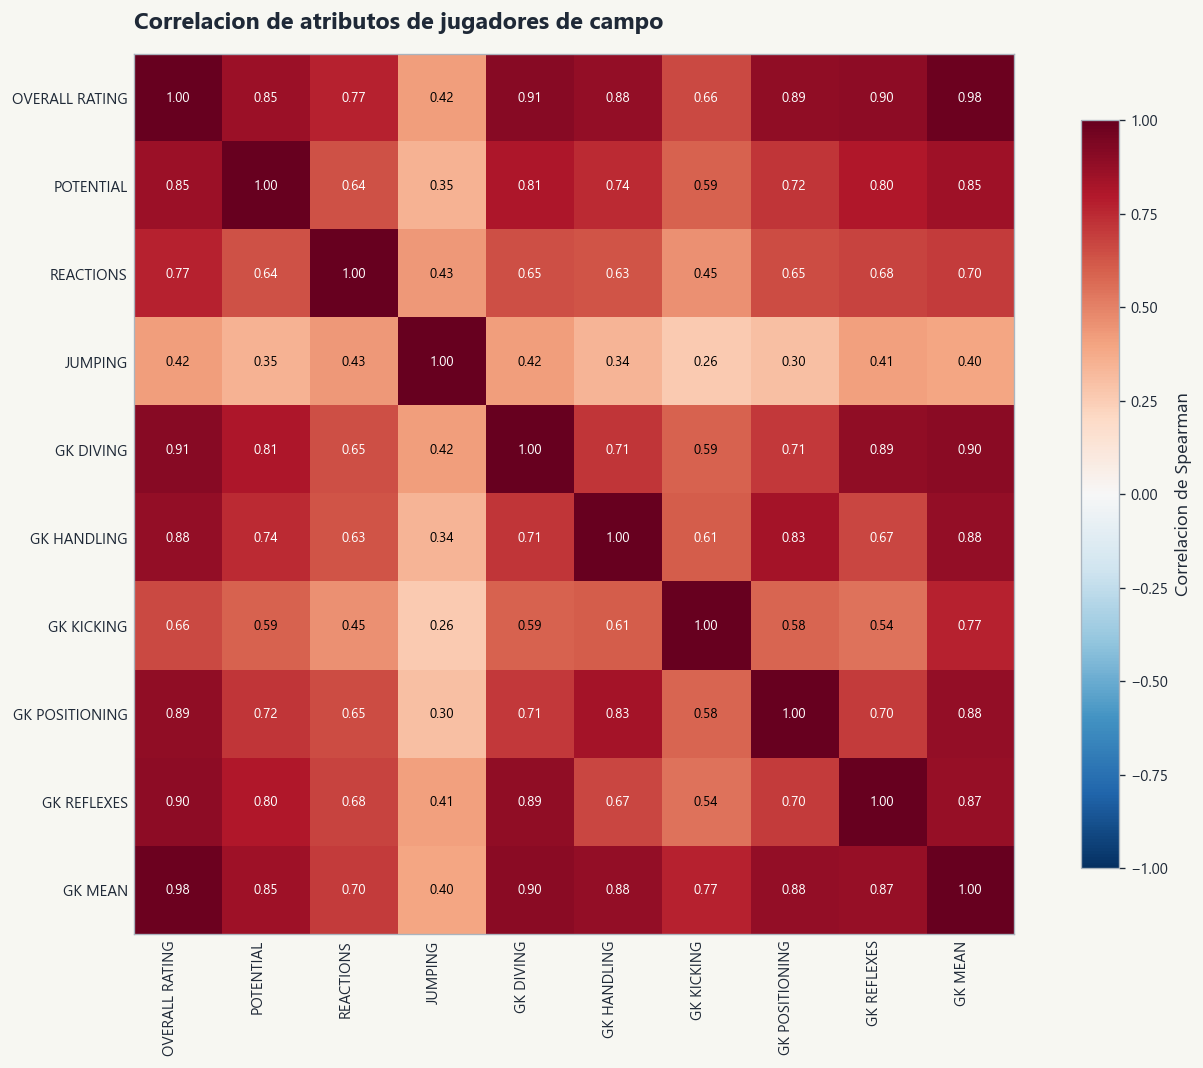

In [13]:
# Nos quedamos solo con porteros
df_goalkeepers = df_player_latest_imputed.copy()
df_goalkeepers = df_goalkeepers[df_goalkeepers["PLAYER_TYPE"] == "GOALKEEPER"]

# Seleccionamos atributos relevantes para porteros
cols = [
    "OVERALL_RATING",
    "POTENTIAL",
    "REACTIONS",
    "JUMPING",
    "GK_DIVING",
    "GK_HANDLING",
    "GK_KICKING",
    "GK_POSITIONING",
    "GK_REFLEXES",
    "GK_MEAN"
]

# Calculamos la matriz de correlacion
df_corr = df_goalkeepers[cols].copy()
corr = df_corr.corr(method = "spearman")

# Preparamos labels mas limpios para el grafico
labels = [col.replace("_", " ") for col in corr.columns]

# Graficamos el heatmap
fig, ax = plt.subplots(figsize = (12, 9))
im = ax.imshow(corr.values, cmap = CMAP_CORR, vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.values[i, j]
        color = "white" if abs(value) >= 0.60 else "black"
        text = ax.text(j, i, f"{value:.2f}", ha = "center", va = "center", color = color, fontsize = 8)

ax.set_title("Correlacion de atributos de jugadores de campo", loc = "left", pad = 15)
ax.tick_params(length = 0)

cbar = plt.colorbar(im, ax = ax, shrink = 0.85)
cbar.set_label("Correlacion de Spearman")

fig.tight_layout()
plt.show()

### Analisis del grafico

En el heatmap de porteros se observa una estructura mucho mas concentrada que en jugadores de campo. La variable `OVERALL_RATING` esta fuertemente relacionada con casi todos los atributos especificos de arquero, en especial con `GK_MEAN` (`0.98`), `GK_DIVING` (`0.91`), `GK_REFLEXES` (`0.90`), `GK_POSITIONING` (`0.89`) y `GK_HANDLING` (`0.88`). Esto indica que el rendimiento general del portero esta muy dominado por sus habilidades tecnicas propias del puesto.

Tambien se ven relaciones altas entre atributos internos del arco. Por ejemplo, `GK_DIVING` y `GK_REFLEXES` tienen una correlacion de `0.89`, mientras que `GK_POSITIONING` y `GK_HANDLING` alcanzan `0.83`. Esto sugiere que varios indicadores del portero miden casi la misma calidad subyacente, por lo que existe bastante redundancia entre ellos.

En cambio, `JUMPING` muestra una relacion bastante menor con el bloque principal de variables de arquero. Por ejemplo, su correlacion con `GK_MEAN` es solo de `0.40`. Esto sugiere que el salto aporta informacion complementaria, pero no explica tanto el nivel global del portero como las habilidades tecnicas de atajada, colocacion y reflejos.

En conjunto, este grafico sugiere que para evaluar porteros se puede resumir gran parte del perfil usando pocas variables clave, porque muchas de las metricas del puesto se mueven casi juntas. A diferencia de los jugadores de campo, aqui la redundancia es mas fuerte y el perfil parece estar mas concentrado en un solo bloque de rendimiento especializado.

## Analisis 03: Histograma del gap potencial - overall rating

- PENDIENTE

- Tema: Distribucion del margen de desarrollo de los jugadores.
- Pregunta: Que tan comun es encontrar jugadores con una brecha grande entre su potencial y su rendimiento actual?
- Que se calcula?: La distribucion de la variable potential - overall_rating para medir cuanto margen de crecimiento tiene cada jugador.
- Datos a usar: df_player_latest
- Grafico: Histograma.
- Precauciones: Si quieren una lectura mas limpia, pueden enfocarse en jugadores jovenes; revisar que el dataset no mezcle varios snapshots por jugador; no sacar conclusiones fuertes si no revisan la edad.
- Como identificar si el resultado es relevante?: Si la distribucion muestra una cola derecha clara y permite distinguir entre jugadores con poco margen y jugadores que destacan por su potencial no desarrollado.
- Insight esperado: Definir mejor que tan raro o comun es encontrar prospectos reales y fijar umbrales practicos para shortlist de scouting.

## Analisis 04: Scatterplot de jugadores con alto potencial y overall todavia moderado

- Tema: Identificacion de prospectos de jugadores.
- Pregunta: Que jugadores combinan un potential alto con un overall que todavia no refleja ese techo?
- Que se calcula?: La relacion entre overall_rating y potential, para detectar jugadores alejados de la diagonal con margen de crecimiento.
- Datos a usar: df_player_latest
- Grafico: Scatterplot.
- Precauciones: Si usan edad como color o filtro, calcularla bien; evitar saturar el grafico con demasiadas etiquetas; si es necesario, quedarse con jugadores jovenes.
- Como identificar si el resultado es relevante?: Si aparecen puntos con potential alto y overall medio o bajo, especialmente en edades bajas.
- Insight esperado: Detectar jugadores que pueden ser opciones interesantes de scouting antes de consolidarse.